In [2]:
# Load Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA

In [8]:
# Load the data 
test = pd.read_csv('data/test.csv')
train = pd.read_csv('data/train.csv')

In [9]:
# Separate predictors X from y 
feature_names = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']

X_train = train[feature_names]
y_train = train['DIC']

X_test = test[feature_names]
# y_test - trying to predict 

# 70/30 training test split  - already done for us 

In [10]:
# Fit the scaler ONLY on the training data AND scale only on X - preventing data leakage 
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set : {X_train_scaled.shape[0]:,} tracts')
print(f'Test set     : {X_test_scaled.shape[0]:,} tracts')

Training set : 3,389 tracts
Test set     : 848 tracts


## Fit PCA and Inspect the Variance 

In [11]:
# -- Run the model  -- 
# initalize 
pca = PCA(n_components=4)
# Fit 
pca_fill = pca.fit(X_train_scaled)

# -- Evaluate -- 
# Explained variance 
explained_var = pca.explained_variance_ratio_
# Cumulative variance 
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

In [12]:
# Create a table with Explained & Cumculative variance 
pca_df= pd.DataFrame({
  'component': ['PC1', 'PC2', 'PC3', 'PC4'],
  'explained_var' : explained_var, 
  'cumulative_var' : cumulative_var,
})

pca_df

,component,explained_var,cumulative_var
0,PC1,0.789091,0.789091
1,PC2,0.111665,0.900757
2,PC3,0.075478,0.976234
3,PC4,0.023766,1.000000


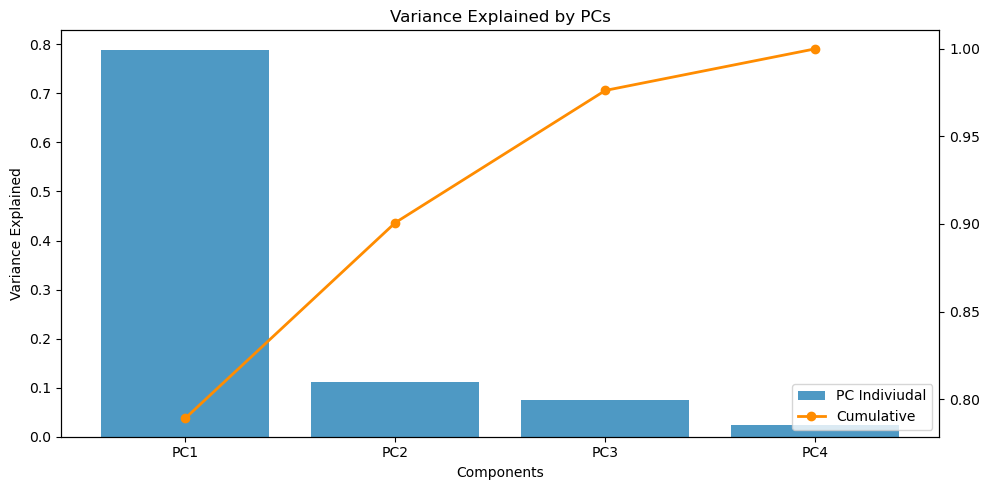

In [13]:
# Bar chart showing the individual explained variance (%) for each component
# Line plot overlaid showing the cumulative explained variance (%)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart on ax1
ax1.bar(pca_df['component'], pca_df['explained_var'], color = "#4e99c4", label='PC Indiviudal')

# Line plot (second y-axis sharing same x)
ax2 = ax1.twinx()
ax2.plot(pca_df['component'], pca_df['cumulative_var'], color = "darkorange",  marker='o', linewidth=2, label='Cumulative')

ax1.set_xlabel("Components")
ax1.set_ylabel("Variance Explained")
ax1.set_title("Variance Explained by PCs")

# Combind Legends 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'lower right')

plt.tight_layout()
plt.show()

**Discussion about accuracy scores and CM**
You need only 3 PCs to catch >95% of the variance. 

## Fit the Final PCR Model 

In [ ]:
best_k = 3

pca_final = PCA(n_components=best_k).fit(X_train_scaled)

X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# Initalize & Fit linear regression (with transformed data)
ols_pcr = LinearRegression().fit(X_train_pca, y_train)

# Evaluate  
y_pred_pcr = ols_pcr.predict(X_test_pca)

y_pred_pcr

submission = pd.DataFrame({"id": test["id"], "DIC": y_pred_pcr})
#submission.to_csv("submission.csv", index=False)


# Dont have y_test 
# mse_pcr = mean_squared_error(y_test, y_pred_pcr)

In [27]:
submission

,id,DIC
0,6,2027.289850
1,8,2065.846164
2,12,1975.112304
3,14,1952.967328
4,17,2110.470400
...,...,...
843,4215,2108.085826
844,4222,2021.835935
845,4226,1961.306681
846,4228,2045.703773


In [ ]:
submission.to_csv("submission.csv", index=False)